# Introduction

In this first notebook, I have downloaded the dataset from the [UK National Grid website](https://www.nationalgrideso.com/data-portal/historic-demand-data). I have perfomed data wrangling and EDA with Pandas, Seaborn and Matplotlib in order to better understand the trends in the time series. This helped during feature engineering and model selection perfomed in the next notebook.

In [1]:
import datetime
import json
import os, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")

In [2]:
from energy_forecast.data.load import load_raw_data

# Load data


In [3]:
os.chdir("..") 
df = load_raw_data()

# EDA

The goals are:
- data cleaning and preprocessing (null values, outliers, unneeded information)
- grasp seasonal trends and understand the data

In [4]:
df.tail()

,settlement_date,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,...,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,nsl_flow,eleclink_flow,scottish_transfer,viking_flow,is_holiday
264811,2024-02-08,44,30670,32324,28979,3855,6562,0,15905,0,...,-4,439,-452,-531,999,-55.0,997.0,5754.0,0.0,0
264812,2024-02-08,45,28684,30714,27230,3873,6562,0,15905,0,...,-4,141,-451,-531,897,-432.0,997.0,5764.0,0.0,0
264813,2024-02-08,46,27147,29324,25762,3890,6562,0,15905,0,...,-4,139,-452,-531,893,-465.0,997.0,5695.0,-13.0,0
264814,2024-02-08,47,25356,28595,24042,3872,6562,0,15905,0,...,-4,-102,-406,-490,996,-284.0,996.0,5745.0,-561.0,0
264815,2024-02-08,48,24286,27944,23034,3853,6562,0,15905,0,...,-4,-110,-351,-385,999,-284.0,996.0,5491.0,-594.0,0


This dataset is from the Great Britain National Grid Electricity System Operator (ESO). It contains information about the electricity demand from 2009 to 2024, updated haf-hourly. We then have enough data per day for time series forecasting.

The columns represent:

- SETTLEMENT_DATE: date in format dd/mm/yyyy
- SETTLEMENT_PERIOD: half hourly period for the historic outturn occurred
- ND (National Demand). National Demand is the sum of metered generation, but excludes generation required to meet station load, pump storage pumping and interconnector exports. National Demand is calculated as a sum of generation based on National Grid ESO operational generation metering. Measured in MW.
- TSD (Transmission System Demand). Transmission System Demand is equal to the ND plus the additional generation required to meet station load, pump storage pumping and interconnector exports. Measured in MW.
- ENGLAND_WALES_DEMAND. England and Wales Demand, as ND above but on an England and Wales basis. Measured in MW.
- EMBEDDED_WIND_GENERATION. This is an estimate of the GB wind generation from wind farms which do not have Transmission System metering installed. These wind farms are embedded in the distribution network and invisible to National Grid ESO. Their effect is to suppress the electricity demand during periods of high wind. The true output of these generators is not known so an estimate is provided based on National Grid ESO’s best model. Measured in MW.
- EMBEDDED_WIND_CAPACITY. This is National Grid ESO’s best view of the installed embedded wind capacity in GB. This is based on publicly available information compiled from a variety of sources and is not the definitive view. It is consistent with the generation estimate provided above. Measured in MW
- EMBEDDED_SOLAR_GENERATION. This is an estimate of the GB solar generation from PV panels. These are embedded in the distribution network and invisible to National Grid ESO. Their effect is to suppress the electricity demand during periods of high radiation. The true output of these generators is not known so an estimate is provided based on National Grid ESO’s best model. Measured in MW.
- EMBEDDED_SOLAR_CAPACITY. As embedded wind capacity above, but for solar generation. Measured in MW.
- NON_BM_STOR (Non-Balancing Mechanism Short-Term Operating Reserve). For units that are not included in the ND generator definition. This can be in the form of generation or demand reduction. Measured in MW.
- PUMP_STORAGE_PUMPING. The demand due to pumping at hydro pump storage units; the -ve signifies pumping load.
- IFA_FLOW (IFA Interconnector Flow). The flow on on the respective interconnector. -ve signifies export power out from GB; +ve signifies import power into GB. Measured in MW.
- IFA2_FLOW (IFA Interconnector Flow). The flow on the respective interconnector. -ve signifies export power out from GB; +ve signifies import power into GB. Measured in MW.
- BRITNEY_FLOW = The flow on the respective interconnector. -ve signifies export power out from GB; +ve signifies import power into GB. Measured in MW.
- MOYLE_FLOW (Moyle Interconnector FLow). The flow on the respective interconnector. -ve signifies export power out from GB; +ve signifies import power into GB. Measured in MW.
- EAST_WEST_FLOW (East West Innterconnector FLow). The flow on the respective interconnector. -ve signifies export power out from GB; +ve signifies import power into GB. Measured in MW.
- NEMO_FLOW (Nemo Interconnector FLow). The flow on the respective interconnector. -ve signifies export power out from GB; +ve signifies import power into GB. Measured in MW.
- NSL_FLOW (North Sea Link Interconnector Flow). The flow on the respective interconnector. -ve signifies export power out from GB; +ve signifies import power into GB. Measured in MW.
- ELCLINK_FLOW: The flow on the respective interconnector. -ve signifies export power out from GB; +ve signifies import power into GB. Measured in MW.
- SCOTTISH_TRANSFER = The volume of power flowing from Scotland to England and Wales. Negative values denote a flow from England and Wales to Scotland. Measured in MW.
- VIKING_FLOW = The flow on the respective interconnector. -ve signifies export power out from GB; +ve signifies import power into GB. Measured in MW.

All flows are from the submarine cables linking the electrity grids of multiple regions of the UK nationally and internationally.

In [5]:
df = df.sort_values(by= ['settlement_date', 'settlement_period']).reset_index(drop=True)

In [6]:
df.shape

(264816, 22)

In [7]:
df.describe()

,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,...,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,nsl_flow,eleclink_flow,scottish_transfer,viking_flow,is_holiday
count,264816.000000,264816.000000,264816.000000,264816.000000,264816.000000,264816.000000,264816.000000,264816.000000,264816.000000,264816.000000,...,264816.000000,264816.000000,264816.00000,264816.000000,264816.000000,89520.000000,89520.000000,19392.000000,19392.000000,264816.000000
mean,24.500227,31504.537358,32921.045749,28667.755774,1242.966573,4331.097245,829.066148,8219.825075,7.017265,311.785629,...,27.051949,522.169559,-116.40814,-36.193897,158.027751,299.353318,26.886092,1715.635262,48.664501,0.022838
std,13.853818,7814.098007,7718.003064,7081.245993,949.364302,1943.416081,1637.697117,5676.571492,40.172911,536.573773,...,325.820897,526.095096,227.41281,255.713040,403.361103,589.323838,438.183194,1882.476750,247.753671,0.149389
min,1.000000,13367.000000,0.000000,0.000000,0.000000,1403.000000,0.000000,0.000000,-24.000000,0.000000,...,-1030.000000,-1215.000000,-505.00000,-585.000000,-1022.000000,-1455.000000,-1028.000000,-2851.000000,-1465.000000,0.000000
25%,12.750000,25248.000000,26897.000000,22976.000000,538.000000,2087.000000,0.000000,1930.000000,0.000000,8.000000,...,0.000000,0.000000,-271.00000,-164.000000,0.000000,0.000000,0.000000,232.000000,0.000000,0.000000
50%,24.500000,30890.000000,32124.000000,28103.000000,994.000000,4260.000000,0.000000,10500.000000,0.000000,11.000000,...,0.000000,748.000000,-134.00000,0.000000,0.000000,0.000000,0.000000,1540.000000,0.000000,0.000000
75%,36.250000,37250.000000,38415.250000,33916.000000,1687.000000,6488.000000,792.000000,13080.000000,0.000000,400.000000,...,0.000000,994.000000,37.00000,0.000000,61.000000,693.000000,0.000000,3071.000000,0.000000,0.000000
max,50.000000,59095.000000,60147.000000,53325.000000,5587.000000,6574.000000,9830.000000,15954.000000,893.000000,2019.000000,...,1016.000000,1143.000000,499.00000,504.000000,1033.000000,1401.000000,1002.000000,6238.000000,1412.000000,1.000000


In [8]:
df.isnull().sum()

settlement_date                   0
settlement_period                 0
nd                                0
tsd                               0
england_wales_demand              0
embedded_wind_generation          0
embedded_wind_capacity            0
embedded_solar_generation         0
embedded_solar_capacity           0
non_bm_stor                       0
pump_storage_pumping              0
ifa_flow                          0
ifa2_flow                         0
britned_flow                      0
moyle_flow                        0
east_west_flow                    0
nemo_flow                         0
nsl_flow                     175296
eleclink_flow                175296
scottish_transfer            245424
viking_flow                  245424
is_holiday                        0
dtype: int64

In [9]:
def existing_years(df: pd.DataFrame, column: str) -> np.ndarray:
    not_null_mask = df[column].notna()
    years = df.loc[not_null_mask, "settlement_date"].str[:4].unique()
    return years

In [10]:
existing_years(df, "eleclink_flow"), existing_years(df, "nsl_flow"), existing_years(df, "scottish_transfer"), existing_years(df, "viking_flow")

(array(['2019', '2020', '2021', '2022', '2023', '2024'], dtype=object),
 array(['2019', '2020', '2021', '2022', '2023', '2024'], dtype=object),
 array(['2023', '2024'], dtype=object),
 array(['2023', '2024'], dtype=object))

The four features contain null values on about 70% to 90% of the dataset and only have values from recent years (2019 and 2023). It appears reasonable to drop them.

Rows where the settlement_period is greater than 48 will also be removed as they are likely to errors during data logging.

In [11]:
df.drop(columns=["eleclink_flow","nsl_flow","scottish_transfer","viking_flow"])
df = df[df["settlement_period"] <= 48].reset_index(drop=True)

We need to change the date format to include the hourly values by leveraging the settlement_period column. There are 48 samples a day, therefore a sample is taken every 30 minutes.

In [12]:
# Build proper datetime index
df["period_hour"] = df["settlement_period"].apply(
    lambda x: str(datetime.timedelta(hours=(x - 1) * 0.5))
)
df.loc[df["period_hour"] == "1 day, 0:00:00", "period_hour"] = "0:00:00"
df["settlement_date"] = pd.to_datetime(df["settlement_date"] + " " + df["period_hour"])
df = df.set_index("settlement_date").sort_index()

In [13]:
df = df.drop(columns=["period_hour"])

Now that the datetime index has been set, we can have a better look at the overall time series patterns, as well as yearly, monthly and daily trends.

### Overall time series trends

<Axes: title={'center': 'National Demand from 2009 to 2024'}, xlabel='settlement_date'>

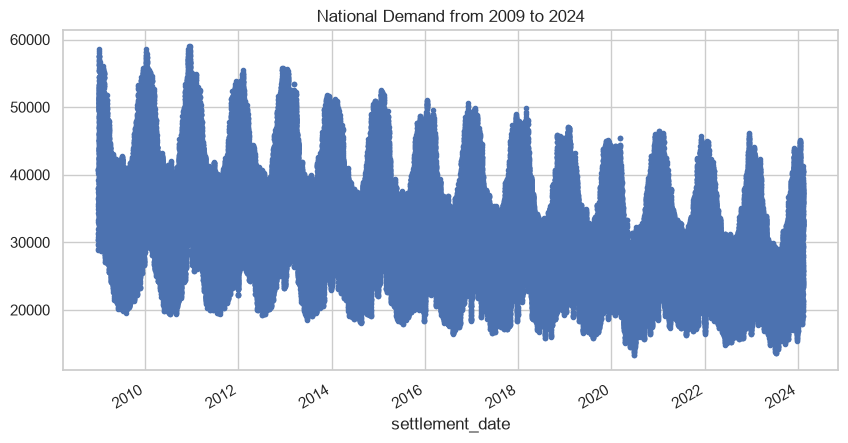

In [14]:
df['nd'].plot(style = '.', title= 'National Demand from 2009 to 2024', figsize = (10, 5))

In [15]:
df_all = df.resample('YE').mean()
df_yearly = df.resample('3W').mean()

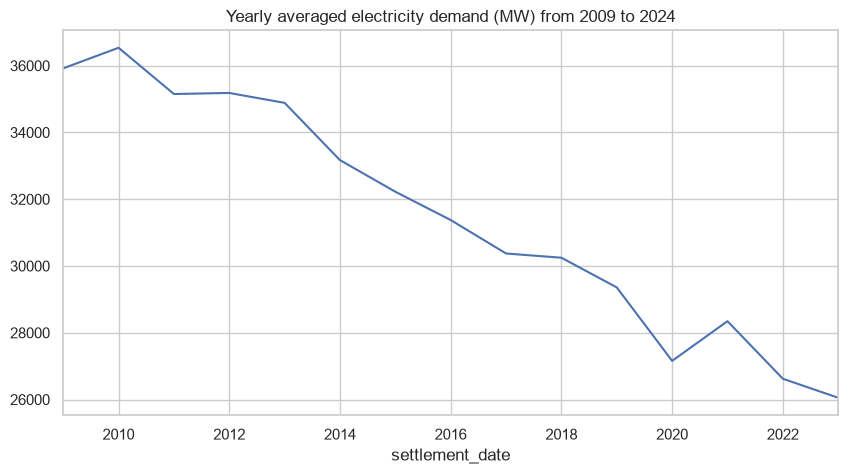

In [16]:
df_all.loc[(df_all.index > '01-01-2009 00:00:00') & (df_all.index < '01-01-2024 00:00:00')]['nd'].plot(
    figsize = (10, 5), title="Yearly averaged electricity demand (MW) from 2009 to 2024"
);

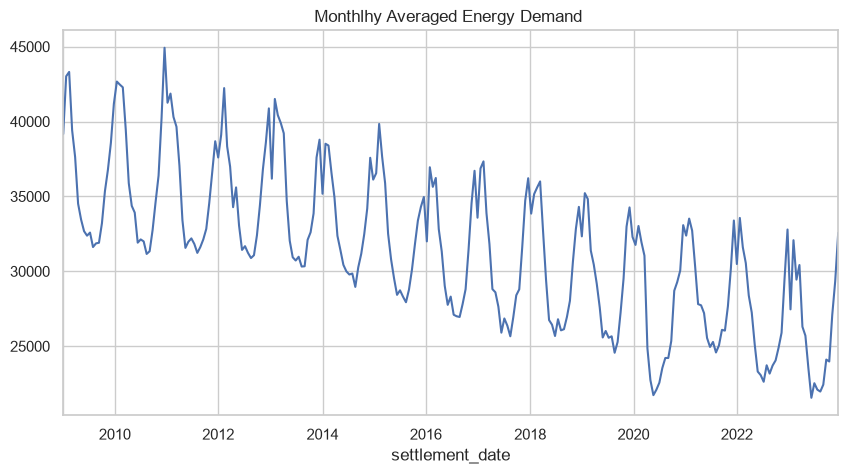

In [17]:
df_yearly.loc[(df_yearly.index > '01-01-2009 00:00:00') & (df_yearly.index < '01-01-2024 00:00:00')]['nd'].plot(
    figsize = (10, 5), title="Monthlhy Averaged Energy Demand "
);

Overall decrease from 2009 to 2024, with about the same yearly trends, except for the abrupt decrease in the first quarter of 2020 due to the first COVID-19 lockdown.

### Yearly patterns

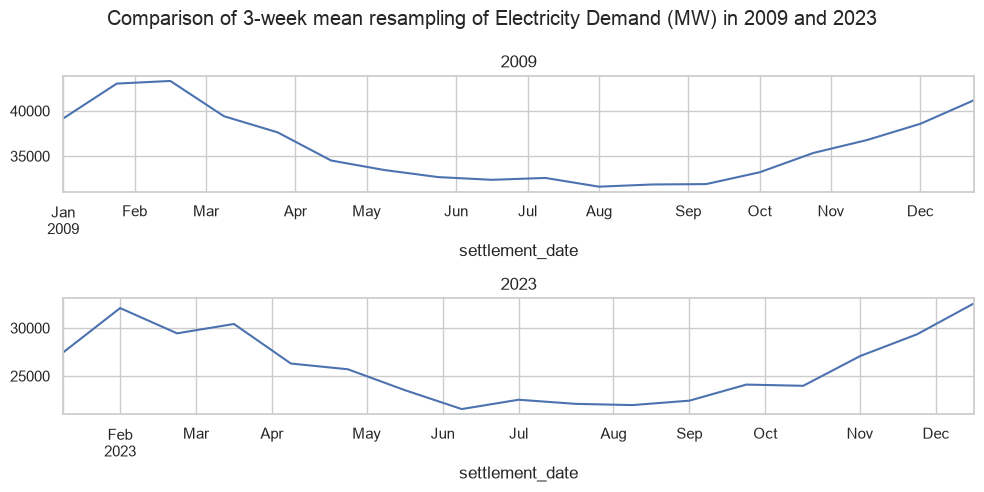

In [18]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharey=False, figsize=(10, 5))

df_yearly.loc[(df_yearly.index > '01-01-2009') & (df_yearly.index < '01-01-2010')]['nd'].plot(ax=ax[0])
ax[0].set_title("2009")

df_yearly.loc[(df_yearly.index > '01-01-2023') & (df_yearly.index < '01-01-2024')]['nd'].plot(ax=ax[1])
ax[1].set_title("2023")

fig.suptitle("Comparison of 3-week mean resampling of Electricity Demand (MW) in 2009 and 2023")
plt.tight_layout()
plt.show()

Same seasonal trends over the years, with a peak in energy during winter and a steep decrease in summer. in 2023, The small different fluctuations may be due to the disrupted and unpredictable weather due to climatic change , if we assume that temperature is the main contributer to energy consumption (look at uk main contributor to energy).

### Weekly and daily trends

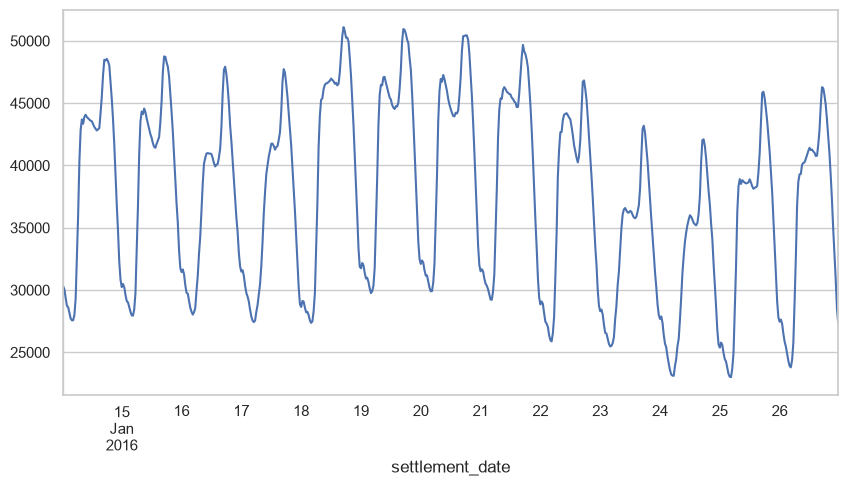

In [19]:
df.loc[(df.index > '01-14-2016') & (df.index < '01-27-2016')]['nd'].plot(
    figsize = (10, 5)
);

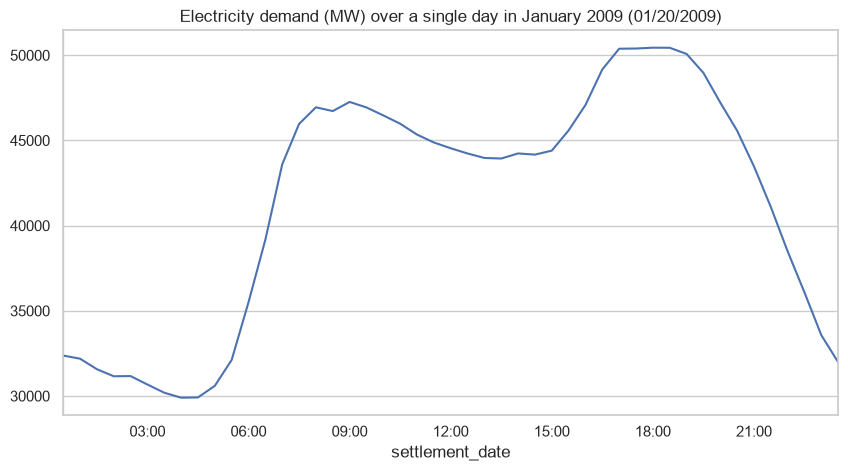

In [20]:
df.loc[(df.index > '01-20-2016 00:00:00') & (df.index < '01-21-2016 00:00:00')]['nd'].plot(
    figsize = (10, 5), title="Electricity demand (MW) over a single day in January 2009 (01/20/2009)"
);

In [21]:
def create_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create calendar-based time series features from the datetime index.

    Args:
        df: time series dataframe with a datetime index

    Returns:
        df: copy of the input dataframe with added calendar features
    """
    df = df.copy()
    df["day_of_month"] = df.index.day
    df["day_of_week"] = df.index.day_of_week
    df["day_name"] = df.index.day_name()
    df["hour"] = df.index.hour
    df["day_of_year"] = df.index.day_of_year
    df["quarter"] = df.index.quarter
    df["month"] = df.index.month
    df["year"] = df.index.year
    df["week_of_year"] = df.index.isocalendar().week.astype("int64")
    return df

In [22]:
df_ext = create_calendar_features(df)

In [23]:
def plot_demand_boxplot(df, x, hue=None, title="", xlabel="", figsize=(10, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(x=x, y="nd", data=df, hue=hue, ax=ax)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel("Electricity demand (MW)")
    ax.set_title(title)
    return fig, ax

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Energy Demand with hours'}, xlabel='Hour', ylabel='Electricity demand (MW)'>)

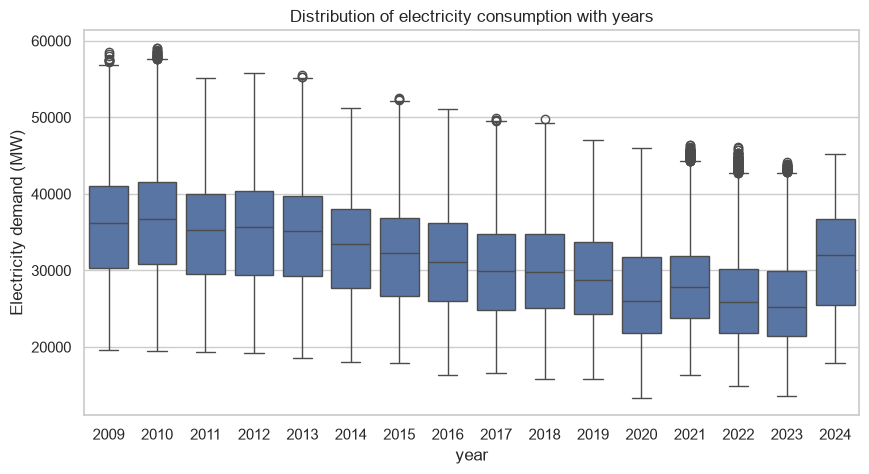

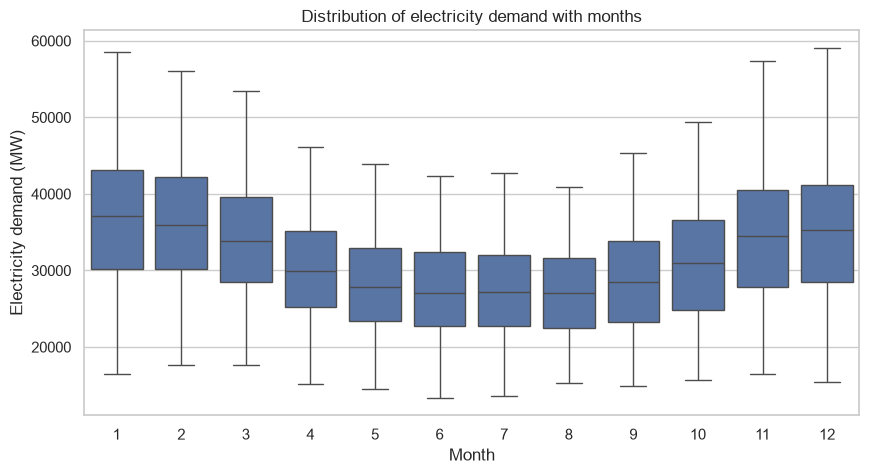

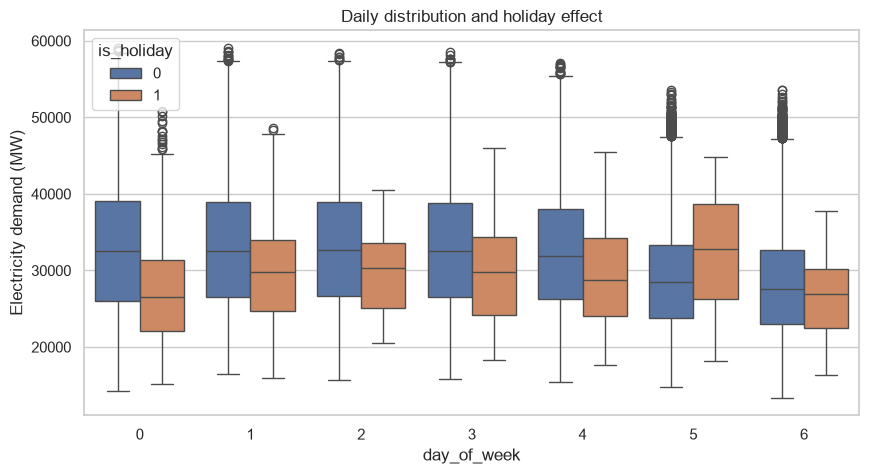

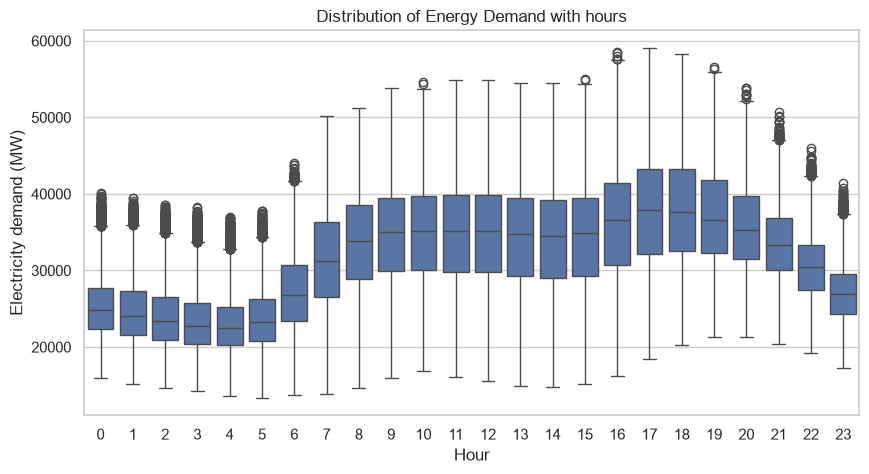

In [24]:
plot_demand_boxplot(df_ext, x="year", title="Distribution of electricity consumption with years")
plot_demand_boxplot(df_ext, x="month", title="Distribution of electricity demand with months", xlabel="Month")
plot_demand_boxplot(df_ext, x="day_of_week", hue="is_holiday", title="Daily distribution and holiday effect")
plot_demand_boxplot(df_ext, x="hour", title="Distribution of Energy Demand with hours", xlabel="Hour")

From these charts, we can see that energy usage ramps up from 6 am to 9 am and again from 3 pm to 6 pm.
At 12 am to 3 pm our energy usage remains stable.
It typically drops after the start and end of the day (likely when most people are asleep).
The demand for winter is about twice as low as the demand for summer.

# Seasonal-Trend Decomposition (MSTL)

So far, seasonality and trend have been assessed visually, by resampling and
plotting the data at different time scales. This section formalises that
analysis using Multiple Seasonal-Trend decomposition using Loess (MSTL), which
splits the series into a trend component, one seasonal component per specified
period, and a residual.

Two seasonalities are decomposed: daily (48 half-hourly steps) and weekly (336
steps). Yearly seasonality is excluded, since it is computationally expensive
at half-hourly resolution and the earlier monthly-averaged plots already show
the yearly pattern clearly.

This decomposition serves two purposes:
1. **Objective lag selection.** The amplitude of each seasonal component gives
   a quantified basis for which lags to prioritise later, rather than relying
   only on visual inspection of autocorrelation plots.
2. **Outlier detection.** The residual, once trend and seasonality are removed,
   is used for outlier detection in the next section. Detecting outliers on raw
   demand values would incorrectly flag normal seasonal extremes (e.g. winter
   peak demand) as anomalous.

### MSTL computation

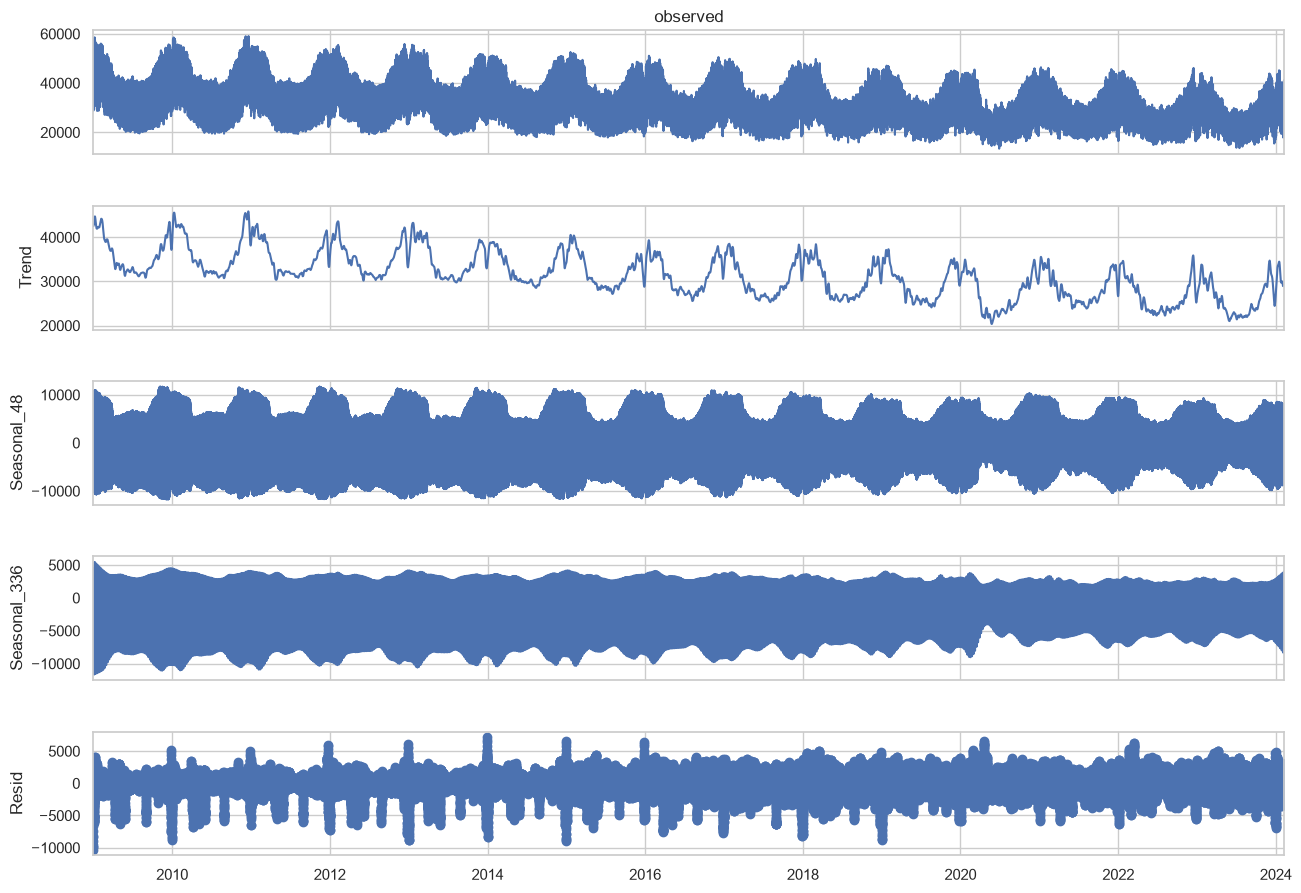

In [25]:
from statsmodels.tsa.seasonal import MSTL

mstl = MSTL(df['nd'], periods=[48, 48 * 7])
result = mstl.fit()

fig = result.plot()
fig.set_size_inches(15, 10)

In [26]:
trend = result.trend
seasonal_daily = result.seasonal["seasonal_48"]
seasonal_weekly = result.seasonal["seasonal_336"]
residual = result.resid

In [29]:
print("Daily seasonal amplitude:", seasonal_daily.max() - seasonal_daily.min())
print("Weekly seasonal amplitude:", seasonal_weekly.max() - seasonal_weekly.min())

Daily seasonal amplitude: 23396.091336759528
Weekly seasonal amplitude: 17123.30817435516


### Observations from the decomposition

The decomposition confirms and quantifies patterns that were previously only assessed
visually.

**Trend.** The declining trend identified in the earlier resampled plots is confirmed
here: mean demand has fallen steadily from the 2009 peaks to 2024, consistent with
long-term improvements in energy efficiency and structural shifts in UK electricity
consumption. A clear dip is visible around 2020, coinciding with COVID-19 lockdowns,
which supports the reliability of the decomposition, as it correctly isolates a
known real-world event rather than treating it as noise.

**Daily seasonality (period 48).** The within-day demand swing is the dominant
seasonal component by amplitude, consistently larger than the weekly component
throughout the series. Its amplitude appears to shrink somewhat in later years,
suggesting the difference between day and night demand has compressed over time.

**Weekly seasonality (period 336).** The weekday/weekend pattern is present but
consistently smaller in amplitude than the daily pattern. There is a visible widening
after around 2020, which may reflect a shift in weekly demand rhythm following changes
in work patterns (e.g. increased remote work).

**Residual.** The residual is reasonably stable in variance across the full period,
with no obvious remaining trend, suggesting the two seasonal components account for
most of the systematic daily/weekly structure. The residual's spikes are examined
for outliers in the next section.

**Implication for feature selection.** The daily seasonal component has a larger
amplitude (~23,396 MW) than the weekly component (~17,123 MW), roughly 1.4 times
larger. This confirms daily lags are likely to carry more predictive signal than
weekly lags, and should be prioritised accordingly when constructing lag features.
However, the weekly component's amplitude is still substantial relative to the
daily one, so weekly lags remain worth including rather than discarding.

# Optimal window width selection through Discrete Fourier Transform

A DFT analysis of the demand series confirms the two seasonalities used in the
MSTL decomposition: a dominant peak at ~48 steps (daily cycle) and a second
peak at ~336 steps (weekly cycle), along with their respective harmonics
(~24 and ~168 steps). The remaining top components correspond to very long
periods (multiple years), which reflect the series' non-periodic long-term
trend rather than genuine cyclical structure, consistent with the declining
trend identified in the MSTL decomposition.

In [30]:
from scipy.fft import rfft, rfftfreq

# DFT to confirm dominant periodicities
n = len(df['nd'].dropna())
yf = rfft(df['nd'].dropna().values)
xf = rfftfreq(n, d=1)  # d=1 since data is evenly spaced in "steps"

power = np.abs(yf) ** 2
periods = 1 / xf[1:]  # skip xf[0] (zero frequency / mean)

# Find the periods (in steps) with the highest power
top_indices = np.argsort(power[1:])[::-1][:10]
top_periods = periods[top_indices]
print(top_periods)

[4.79945623e+01 1.76524000e+04 2.64786000e+05 2.39972811e+01
 3.36022843e+02 1.32393000e+05 4.81254089e+01 1.68011421e+02
 6.61965000e+04 5.29572000e+04]


### Outlier detection — Rolling Window Approach

Since the residual's variance is not constant over time (as shown above), a rolling
window is used to compute a local median and MAD around each point, rather than one
fixed threshold for the whole series. This adapts the outlier threshold to the local
spread of the residual, rather than assuming it stays constant across 16 years of data.

In [34]:
window = 48 * 30  # roughly one month of half-hourly steps

rolling_median = residual.rolling(window, center=True, min_periods=window // 2).median()
rolling_mad = (residual - rolling_median).abs().rolling(window, center=True, min_periods=window // 2).median()

rolling_z = 0.6745 * (residual - rolling_median) / rolling_mad

outlier_mask_rolling = rolling_z.abs() > 3.5
outliers_rolling = df[outlier_mask_rolling]

print(f"{outlier_mask_rolling.sum()} points flagged as outliers ({outlier_mask_rolling.mean():.2%} of data)")

3498 points flagged as outliers (1.32% of data)


Text(0.5, 1.0, 'Flagged outliers (rolling window) on national demand')

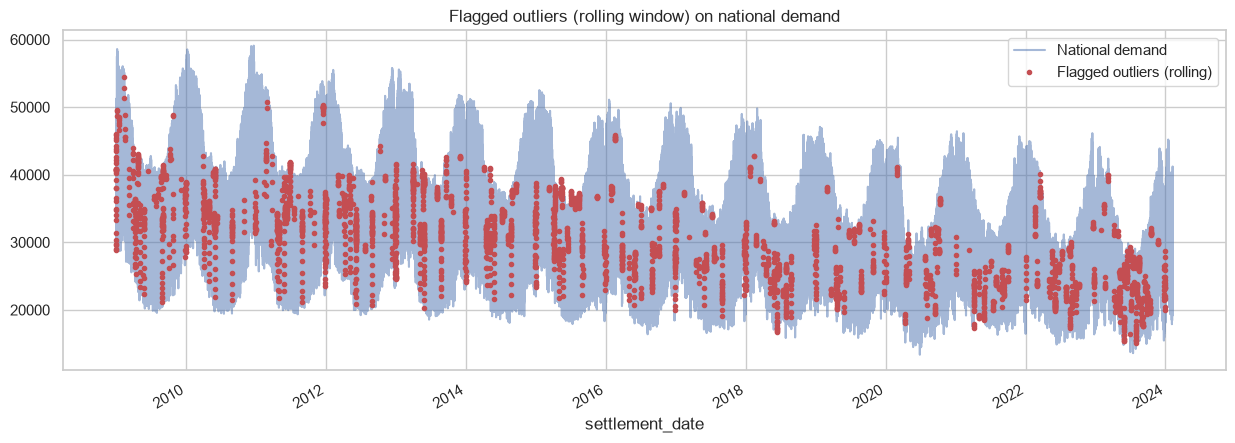

In [35]:
fig, ax = plt.subplots(figsize=(15, 5))
df['nd'].plot(ax=ax, alpha=0.5, label='National demand')
df.loc[outlier_mask_rolling, 'nd'].plot(ax=ax, style='r.', label='Flagged outliers (rolling)')
ax.legend()
ax.set_title('Flagged outliers (rolling window) on national demand')

In [36]:
outliers_rolling.index.to_series().dt.year.value_counts().sort_index()

settlement_date
2009    299
2010    217
2011    297
2012    288
2013    309
2014    226
2015    255
2016    220
2017    143
2018    209
2019    158
2020    144
2021    133
2022    250
2023    338
2024     12
Name: count, dtype: int64

### Outlier Detection — Conclusion

A rolling-window robust z-score (window = 1 month, threshold 3.5) flags 3,498 points
(1.32% of the data) — fewer than the global method, and more evenly distributed across
years, confirming the earlier finding that the global method's results were partly
driven by non-constant residual variance rather than genuine anomalies.

However, the flagged points still do not show a clear signature of discrete,
identifiable events (e.g. 2020, the COVID-affected year, does not stand out with an
elevated count). This suggests the flagged points largely represent normal demand
variability rather than data errors, sensor faults, or clearly anomalous events.

Given this, no points are removed from the dataset. Electricity demand data of this
kind is not expected to contain sensor-driven outliers in the way instrumentation
data might; extreme or unusual values are more likely to reflect genuine demand
conditions (unusual weather, atypical consumption patterns) than errors. This
conclusion is consistent with the observation, made in the original 2024 thesis
version of this analysis, that no clear evidence of erroneous outliers was found,
though it is now supported by a quantified, reproducible method rather than visual
inspection alone.

# Autocorrelation Analysis (ACF/PACF)

While MSTL and the DFT analysis confirmed daily and weekly seasonality as the
dominant periodicities, they do not directly indicate which specific lag values
carry the most useful information for forecasting. ACF (autocorrelation function)
and PACF (partial autocorrelation function) are used here to quantify the
correlation between demand and its own past values at specific lags, providing
an objective basis for the lag features to be constructed in the next notebook.

PACF specifically isolates the *direct* contribution of each lag, removing the
indirect correlation carried through intervening lags — useful for identifying
which lags add genuinely new information versus which are simply echoing an
earlier, more fundamental lag.

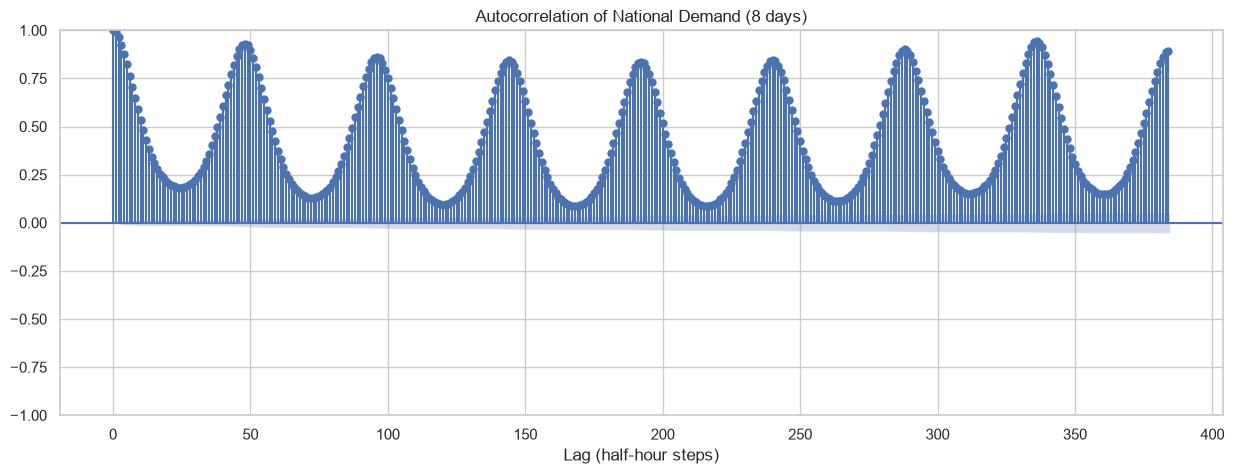

In [37]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(15, 5))
plot_acf(df['nd'], lags=48 * 8, ax=ax)
ax.set_title("Autocorrelation of National Demand (8 days)")
ax.set_xlabel("Lag (half-hour steps)")
plt.show()

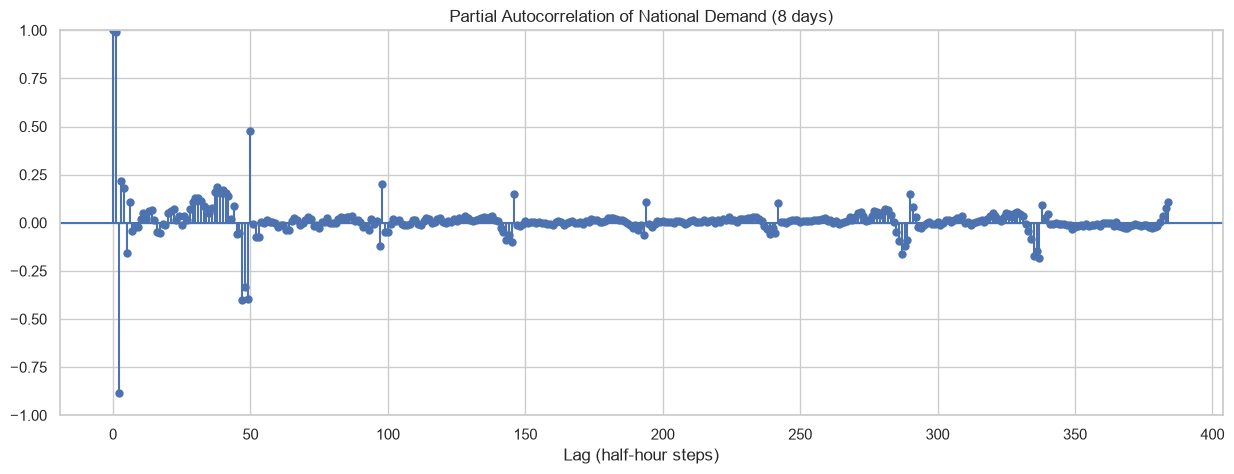

In [38]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(15, 5))
plot_pacf(df['nd'], lags=48 * 8, method='ywm', ax=ax)
ax.set_title("Partial Autocorrelation of National Demand (8 days)")
ax.set_xlabel("Lag (half-hour steps)")
plt.show()

In [39]:
from statsmodels.tsa.stattools import acf, pacf

acf_values = acf(df['nd'], nlags=48 * 8)
pacf_values = pacf(df['nd'], nlags=48 * 8, method='ywm')

candidate_lags = [48, 96, 144, 192, 240, 288, 336]  # 1–6 days, 1 week

lag_comparison = pd.DataFrame({
    "acf": [acf_values[lag] for lag in candidate_lags],
    "pacf": [pacf_values[lag] for lag in candidate_lags],
}, index=candidate_lags)

lag_comparison.sort_values("pacf", ascending=False)

,acf,pacf
96,0.863064,0.011132
192,0.837542,-0.011615
240,0.846966,-0.026023
144,0.843344,-0.064539
288,0.901714,-0.122286
336,0.945700,-0.144511
48,0.930682,-0.332713


### Conclusion — Lag Selection

While ACF shows correlation at every multiple of 48 half-hour steps, PACF reveals
that most of this is indirect: once lag 48 (1 day) is accounted for, lags at 96,
144, 192, 240, and 288 (2–6 days) each show negligible partial autocorrelation
(|PACF| < 0.07), meaning they carry little independent predictive information
beyond what lag 48 already provides. Lag 336 (1 week) is the exception, showing a
meaningfully stronger partial autocorrelation (-0.145), consistent with the weekly
seasonality identified in the MSTL decomposition and DFT analysis.

The very short lags (1 and 2 half-hour steps) show the strongest partial
autocorrelation of all, reflecting the near-continuous nature of electricity demand.

Based on this, the lag features carried forward to the feature engineering stage
are: lag 1, lag 2, lag 48 (1 day), and lag 336 (1 week). This is a smaller, evidence-based
set rather than the broader intuitively-constructed lag groups (A–E) used in the
original thesis analysis.

# Conclusions and Next Steps

## Data cleaning
The raw dataset was cleaned by removing four columns with 70–90% missing values
(`eleclink_flow`, `nsl_flow`, `scottish_transfer`, `viking_flow`), dropping rows
with erroneous `settlement_period` values above 48, and constructing a proper
half-hourly datetime index from `settlement_date` and `settlement_period`. Columns
that are near-duplicates of the target by definition (`tsd`, `england_wales_demand`,
and interconnector flow columns) were also dropped. Unlike the original thesis
analysis, `embedded_wind_generation` and `embedded_solar_generation` are retained,
since they represent a genuine demand-suppressing driver rather than a duplicate
of the target, and their relevance will be assessed quantitatively (via SHAP) in
a later stage rather than dropped on the basis of a limited OLS test.

## Seasonality and trend
An MSTL decomposition (periods of 48 and 336 half-hour steps) confirmed daily
seasonality as the dominant component (amplitude ~23,396 MW) over weekly
seasonality (~17,123 MW), and revealed a shrinking daily amplitude and a declining
long-term trend, including a visible dip around 2020 consistent with COVID-19.
A DFT analysis independently confirmed the same two dominant periodicities.

## Outliers
Outlier detection was performed on the MSTL residual, using both a global and a
rolling-window robust z-score, to avoid incorrectly flagging normal seasonal
extremes. Neither method produced outliers clustering around specific known
events, suggesting the flagged points reflect normal demand variability rather
than data errors. No points were removed from the dataset.

## Lag selection
ACF and PACF analysis showed that, once lag 48 (1 day) is accounted for, other
daily-multiple lags (2–6 days) carry little independent predictive signal. Lag 336
(1 week) and the very short lags (1–2 half-hour steps) were the exceptions,
retaining meaningful partial autocorrelation. These findings will directly inform
the lag features constructed in the next stage.

## Next steps
The following notebook (`02_feature_engineering.ipynb`) will:
- Merge in the population-weighted temperature series
- Run a Kendall correlation check across all candidate features (including
  temperature and wind/solar generation), replacing the OLS-based approach used
  in the original thesis
- Construct lag features informed by the analysis above, along with rolling
  statistics, degree-days, and cyclical calendar encodings
- Compare MRFO-based feature selection against SHAP importance from a trained
  XGBoost model